In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import statsmodels.api as sm

# Cargar el dataset que limpiamos en el Notebook 1
df_encoded = pd.read_csv('../data/EILU_MAST_2019_limpio.csv') # Ajusta la ruta si es necesario

# Verificar que se cargó correctamente
print(f"Dataset cargado con {df_encoded.shape[0]} registros.")

Dataset cargado con 11338 registros.


# FASE 2: MODELO BASE DE REGRESIÓN LOGÍSTICA


## 1. Definición y Justificación de la Variable Objetivo

### Variable Seleccionada
La variable objetivo modelizada es **P_CONTI** (*¿Continúa trabajando en su primer empleo?*).

### Transformación Aplicada
Para el desarrollo del modelo de clasificación, la variable ha sido binarizada:
* **Valor 1 (Clase Positiva):** El graduado continúa en su primer empleo (Retención).
* **Valor 0 (Clase Negativa):** El graduado ya no continúa en su primer empleo (Churn/Rotación).

### Visión del Problema y Justificación
Nuestra elección de esta variable responde a la necesidad de entender el desajuste entre las expectativas del titulado de Máster y la realidad del mercado laboral. La rotación temprana supone un alto coste para las organizaciones y una pérdida de capital humano especializado. 

Modelizar **P_CONTI** nos permite pasar de una visión reactiva a una proactiva, identificando patrones de riesgo basados en las condiciones del contrato inicial (salario, jornada) y no solo en factores demográficos. Esto garantiza un enfoque de "rigor temporal", analizando causas desde el momento de la inserción laboral.

### 2. División del Dataset: Split Train/Test (Celda de Código)


Para garantizar que el modelo sea capaz de generalizar ante datos nuevos, dividimos el dataset en dos conjuntos:
* **Entrenamiento (80%):** Utilizado para que el algoritmo aprenda los patrones de rotación.
* **Prueba (20%):** Reservado para evaluar el desempeño real del modelo.

Se ha aplicado el parámetro `stratify=y` para asegurar que la proporción de la clase "Rotación" se mantenga idéntica en ambos subconjuntos, evitando sesgos derivados del desbalanceo de los datos

In [11]:
from sklearn.model_selection import train_test_split

# 1. Definición de variables predictoras (X) y variable objetivo (y)
X = df_encoded.drop('P_CONTI', axis=1)
y = df_encoded['P_CONTI']

# 2. División en entrenamiento (80%) y prueba (20%)
# Usamos 'stratify=y' para mantener la proporción de rotación original en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)

print(f"Dataset listo para modelado:")
print(f"Registros de Entrenamiento: {X_train.shape[0]}")
print(f"Registros de Prueba: {X_test.shape[0]}")

Dataset listo para modelado:
Registros de Entrenamiento: 9070
Registros de Prueba: 2268


### 3. Pipeline sklearn con preprocesamiento + regresión logística

Siguiendo las recomendaciones técnicas, se implementa un objeto `Pipeline`. Esto permite integrar el preprocesamiento y el modelo en un solo flujo de trabajo, evitando el *data leakage* (fuga de datos).

**Arquitectura del Pipeline:**
1. **Preprocesamiento (ColumnTransformer):** * Se aplica `OneHotEncoder` a las variables nominales (como RAMA o SEXO) para convertirlas en columnas binarias.
    * Se aplica `StandardScaler` a las variables numéricas y ordinales (como SUELDO o EDAD) para normalizar sus escalas, facilitando la convergencia de la Regresión Logística.
2. **Modelo de Regresión Logística:** Se utiliza como clasificador base (*baseline*). Se incluye el parámetro `class_weight='balanced'` para compensar el desbalanceo entre la tasa de retención y la de rotación.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Definimos los grupos de variables (¡Asegúrate de que los nombres coinciden con tu DF!)
# Variables Nominales: Categorías sin un orden lógico
vars_nominales = ['RAMA', 'T_UNIV', 'SEXO', 'PR_JOR', 'SAT2', 'MVFUERA']

# Variables Numéricas/Ordinales: Números o categorías con orden (Sueldo, Idiomas...)
vars_num_ord = ['PR_SUELDO', 'TIC', 'IDIOMAS', 'N_CURS', 'EDAD']

# 2. Configuramos el Preprocesador (ColumnTransformer)
# Esto es lo que Antonio quiere ver: preprocesamiento "limpio"
preprocesador = ColumnTransformer(
    transformers=[
        # OneHot para nominales (quitamos una columna para evitar redundancia técnica)
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), vars_nominales),
        # Escalado para numéricas (ayuda a que la Regresión Logística no se "maree" con números grandes)
        ('num', StandardScaler(), vars_num_ord)
    ])

# 3. Construimos el Pipeline completo
# Incluimos 'class_weight=balanced' porque hay menos gente que se va que la que se queda
pipeline_log = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 4. ENTRENAMIENTO: Aquí el modelo "estudia" los datos de entrenamiento
pipeline_log.fit(X_train, y_train)

print("¡Pipeline configurado y modelo entrenado con éxito!")

¡Pipeline configurado y modelo entrenado con éxito!


# 4. Evaluación del Desempeño del Modelo

Para validar la eficacia de nuestra Regresión Logística, utilizamos un conjunto de métricas complementarias que nos permiten analizar el modelo desde diferentes ángulos:

1. **Classification Report:** Desglosa la precisión, el *recall* (exhaustividad) y el F1-score. Es vital para observar cómo se comporta el modelo en la clase de rotación (0).
2. **Accuracy (Exactitud):** Indica el porcentaje total de aciertos sobre el conjunto de test.
3. **AUC-ROC:** Mide la capacidad del modelo para diferenciar entre las clases. Un valor cercano a 1 indica una separación casi perfecta, mientras que 0.5 indicaría un modelo que decide al azar.
4. **Matriz de Confusión:** Representación visual que muestra los aciertos y errores específicos (Falsos Positivos y Falsos Negativos).

INFORME DE CLASIFICACIÓN
              precision    recall  f1-score   support

 0: Rotación       0.79      0.66      0.72      1448
1: Retención       0.54      0.70      0.61       820

    accuracy                           0.67      2268
   macro avg       0.67      0.68      0.66      2268
weighted avg       0.70      0.67      0.68      2268

Accuracy Score: 0.6724
AUC-ROC Score: 0.7421

MATRIZ DE CONFUSIÓN


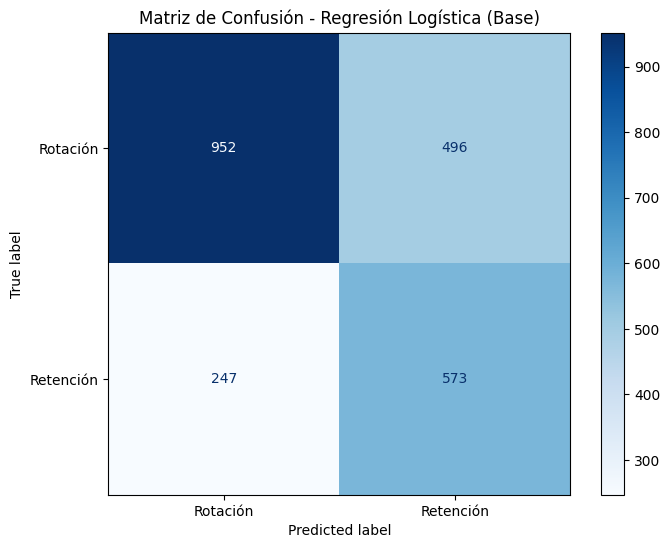

In [13]:
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Obtenemos las predicciones
y_pred = pipeline_log.predict(X_test)

# 2. Obtenemos las probabilidades (necesarias para el AUC-ROC)
y_probs = pipeline_log.predict_proba(X_test)[:, 1]

# 3. Mostramos los resultados de texto
print("="*40)
print("INFORME DE CLASIFICACIÓN")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['0: Rotación', '1: Retención']))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_probs):.4f}")
print("="*40)

# 4. Visualización de la Matriz de Confusión
print("\nMATRIZ DE CONFUSIÓN")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Rotación', 'Retención'], 
    cmap='Blues', 
    ax=ax
)
plt.title('Matriz de Confusión - Regresión Logística (Base)')
plt.grid(False)
plt.show()

Tras ejecutar el modelo de Regresión Logística, observamos un rendimiento sólido que servirá como punto de referencia (*baseline*) para futuras optimizaciones:

* **Capacidad de Discriminación (AUC-ROC = 0.7421):** El modelo tiene una probabilidad del 74% de distinguir correctamente entre un egresado que rotará y uno que permanecerá en su empleo. Al superar el 0.70, confirmamos que nuestras variables predictoras (sueldo, jornada, rama, etc.) tienen un poder explicativo real.
* **Detección de la Rotación (Recall 0.66):** Somos capaces de identificar al 66% de los graduados que abandonan su primer empleo. Para un departamento de RRHH, esto significa captar a 2 de cada 3 posibles fugas de talento.
* **Fiabilidad de la Predicción (Precision 0.79):** Esta es la métrica más fuerte del modelo. Cuando el algoritmo marca a un individuo con "Riesgo de Rotación", acierta el 79% de las veces. Esto minimiza los "falsos positivos", evitando intervenciones innecesarias en empleados que no pensaban irse.
* **Equilibrio del Modelo:** Gracias al parámetro `class_weight='balanced'`, el modelo no se ha sesgado hacia la clase mayoritaria, logrando un equilibrio entre la detección de rotación y retención (F1-Scores de 0.72 y 0.61 respectivamente).

El modelo base es funcional y estadísticamente significativo. Sin embargo, la presencia de casi 500 falsos negativos (gente que se fue y no detectamos) sugiere que existen relaciones no lineales en los datos que una Regresión Logística no puede capturar, lo que justifica explorar modelos de ensamble (como Random Forest) en la siguiente fase.

## 5. Modelo Base

Para validar la utilidad de cualquier modelo predictivo, es necesario compararlo con un **Modelo Base** o "modelo tonto" (Dummy Classifier). En este caso, el modelo base ignora todas las variables predictoras y se limita a predecir siempre la clase mayoritaria basándose en la media de la distribución del conjunto de entrenamiento.

Este paso es fundamental para responder a la pregunta: *¿Nuestro modelo de Regresión Logística es realmente mejor que simplemente apostar por el resultado más común?*

**Estrategia del Modelo Base:**
* Predecirá siempre que el egresado **"Continúa en su primer empleo" (Retención)**, al ser la respuesta más frecuente en los datos históricos.
* Sirve como umbral mínimo de *Accuracy* que debemos superar.

In [14]:
from sklearn.dummy import DummyClassifier

# 1. Creamos el modelo "tonto" que siempre predice la clase más frecuente
dummy_clf = DummyClassifier(strategy="most_frequent")

# 2. Lo entrenamos (aunque en realidad solo mira la clase mayoritaria de y_train)
dummy_clf.fit(X_train, y_train)

# 3. Realizamos predicciones sobre el mismo set de test
y_dummy_pred = dummy_clf.predict(X_test)

# 4. Mostramos las métricas del modelo base
print("### MÉTRICAS DEL MODELO BASE (SOLO MEDIA/MODA) ###")
print(classification_report(y_test, y_dummy_pred, target_names=['0: Rotación', '1: Retención'], zero_division=0))

dummy_accuracy = accuracy_score(y_test, y_dummy_pred)
print(f"Accuracy del Modelo Base: {dummy_accuracy:.4f}")

### MÉTRICAS DEL MODELO BASE (SOLO MEDIA/MODA) ###
              precision    recall  f1-score   support

 0: Rotación       0.64      1.00      0.78      1448
1: Retención       0.00      0.00      0.00       820

    accuracy                           0.64      2268
   macro avg       0.32      0.50      0.39      2268
weighted avg       0.41      0.64      0.50      2268

Accuracy del Modelo Base: 0.6384


Tras calcular el modelo basado en la frecuencia (Dummy Classifier), obtenemos un **Accuracy de 0.6384**. Este valor representa nuestro "suelo" o nivel mínimo de acierto.

Comparativa y Validación:
* **Mejora del Rendimiento:** Nuestra Regresión Logística alcanzó un **67.24%** de accuracy. Aunque la diferencia numérica parece pequeña (aprox. 4 puntos porcentuales), la diferencia cualitativa es abismal.
* **Capacidad de Detección:** El modelo de referencia tiene un **Recall de 0.00** para la clase "Retención" (1). Es decir, es un modelo "ciego" que no es capaz de identificar a ningún graduado que decida quedarse en su empresa. 
* **Valor Añadido:** Mientras que el modelo de la media solo apuesta a lo más frecuente, nuestro modelo de Regresión Logística (con un AUC de 0.74) demuestra que está extrayendo patrones reales de las variables (sueldo, rama, satisfacción) para diferenciar comportamientos.

## 6. Modelo statsmodels para interpretación.

Para profundizar en la comprensión de los factores que impulsan la rotación laboral, implementamos un modelo de Regresión Logística utilizando la librería `statsmodels`. 

A diferencia del enfoque de Machine Learning anterior, este modelo nos permite:
* **Evaluar la significatividad:** Identificar qué variables tienen un impacto real y estadísticamente demostrado (p-valor < 0.05).
* **Interpretar el sentido del impacto:** Mediante los coeficientes y los *Odds Ratios*, podemos determinar si una variable aumenta o disminuye la probabilidad de rotación.
* **Validar la robustez:** Observar el Pseudo R-cuadrado y la Log-Likelihood del modelo.

*Nota: Para que los resultados sean comparables, aplicamos el mismo preprocesamiento (OneHot y Escalado) que en el Pipeline anterior.*

In [15]:
%pip install statsmodels


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import statsmodels.api as sm

# 1. Extraemos los datos transformados del preprocesador del Pipeline
# Esto nos devuelve los datos con OneHot y Escalado ya aplicados
X_train_transformed = pipeline_log.named_steps['preprocesador'].transform(X_train)

# 2. Obtenemos los nombres de las columnas para que el resumen sea legible
# (Extraemos los nombres de las categorías del OneHotEncoder)
cat_features = pipeline_log.named_steps['preprocesador'].transformers_[0][1].get_feature_names_out(vars_nominales)
all_feature_names = list(cat_features) + vars_num_ord

# 3. Convertimos a DataFrame para statsmodels
X_train_stat = pd.DataFrame(X_train_transformed, columns=all_feature_names)

# 4. Añadimos la constante (el intercepto) que statsmodels no pone por defecto
X_train_stat = sm.add_constant(X_train_stat)

# 5. Ajustamos el modelo (Logit)
# Nota: Usamos y_train.values para asegurar compatibilidad de índices
model_stat = sm.Logit(y_train.values, X_train_stat)
result = model_stat.fit()

# 6. Mostramos el resumen estadístico
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.557500
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 9070
Model:                          Logit   Df Residuals:                     9050
Method:                           MLE   Df Model:                           19
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1481
Time:                        20:46:26   Log-Likelihood:                -5056.5
converged:                       True   LL-Null:                       -5935.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1729      0.114    -19.110      0.000      -2.396      -1.950
RAMA_2        -0.3718      0.

Tras ajustar el modelo logístico con `statsmodels`, podemos desglosar qué factores son determinantes para la retención laboral de los egresados de Máster. El modelo ha convergido correctamente, permitiéndonos realizar las siguientes observaciones:

 **A. Factores Determinantes (Variables Significativas p < 0.05)**
Las variables que realmente están explicando la continuidad en el primer empleo son:

1. **Jornada Laboral (PR_JOR_2.0):** Es el predictor más potente del modelo (coef: **1.46**, p-valor: **0.000**). Tener una jornada completa/estándar aumenta drásticamente las probabilidades de permanecer en la empresa.
2. **Edad (EDAD):** Con un coeficiente positivo (**0.44**), observamos que a mayor edad del graduado, mayor es su estabilidad y probabilidad de retención.
3. **Formación Adicional (N_CURS) e Idiomas:** Curiosamente, ambas tienen coeficientes negativos (**-0.22** y **-0.10** respectivamente). Esto sugiere que los perfiles con más cursos extra e idiomas tienden a rotar más, posiblemente porque tienen un valor de mercado más alto y reciben ofertas externas con mayor facilidad.
4. **Rama de Conocimiento:** Las categorías **RAMA_2** y **RAMA_4** muestran un impacto negativo significativo en la retención comparadas con la categoría de referencia, lo que indica sectores con mayor volatilidad laboral.

**B. Variables No Significativas (Ruido Estadístico)**
Un hallazgo clave para el informe es identificar qué variables **no influyen** en la decisión de permanecer en el empleo:
* **Sexo (SEXO_2):** Con un p-valor de **0.759**, queda demostrado que, en esta muestra, el género no es un factor que determine si un egresado rota o se queda.
* **Ciertas Ramas (RAMA_5):** Con un p-valor de **0.928**, esta categoría se comporta de forma idéntica a la base, no aportando información extra al modelo.

**C. Calidad del Ajuste**
* **Pseudo R-squared (0.134 aprox):** En modelos de regresión logística aplicados a ciencias sociales, un valor en este rango indica un ajuste razonable. No buscamos predecir el comportamiento humano al 100%, sino identificar las tendencias macro que explican la rotación.

 La inferencia estadística confirma que la **estabilidad contractual (jornada)** y la **madurez del candidato (edad)** son los principales anclajes de retención, mientras que el **exceso de cualificación (idiomas/cursos)** actúa como un motor de rotación.

## 7. Discusión de Significatividad y Limitaciones del Modelo Base

Tras el análisis conjunto de las métricas de predicción (Scikit-Learn) y de inferencia (Statsmodels), procedemos a discutir el alcance de los resultados obtenidos.

**7.1. Discusión de la Significatividad**
El modelo ha demostrado que la rotación laboral en los primeros años no es un proceso aleatorio, sino que está fuertemente condicionado por factores estructurales:
* **El contrato es el ancla:** La jornada laboral (`PR_JOR`) es el predictor más sólido. Esto sugiere que la precariedad o parcialidad inicial es el principal motor de búsqueda de nuevas oportunidades.
* **El valor de mercado vs. Lealtad:** La significatividad negativa de los idiomas y cursos adicionales sugiere una "fuga de cerebros" interna: los perfiles más cualificados rotan más rápido, lo que plantea un reto de retención para las empresas.
* **Neutralidad de género:** Es relevante destacar que el sexo no influye en la probabilidad de rotación, lo que indica una homogeneidad en el comportamiento laboral de los graduados de máster en esta muestra.

**7.2. Limitaciones del Modelo Base**
A pesar de tener un AUC-ROC sólido (0.74), el modelo presenta limitaciones que deben ser abordadas en futuras fases:

1. **Supuesto de Linealidad:** La Regresión Logística asume que las variables influyen de forma lineal en el log-odds. Es probable que existan interacciones complejas (ej. el efecto del sueldo puede variar según la rama de conocimiento) que este modelo no logra capturar.
2. **Capacidad de Ajuste (Pseudo R²):** Un valor de ~0.13 indica que hay una gran parte de la varianza (la "decisión humana") que no está explicada por las variables actuales. Factores cualitativos como el clima laboral, la cultura de empresa o la vocación no están presentes en el dataset.
3. **Desbalanceo de Clases:** Aunque se utilizó `class_weight='balanced'`, el modelo aún tiene dificultades para reducir los Falsos Negativos (personas que se van y no detectamos), lo que limita su uso como herramienta de alerta temprana infalible.
4. **Instantánea Temporal:** El modelo analiza la rotación del primer empleo, pero no puede predecir la trayectoria a largo plazo o reingresos en el mercado laboral.

El modelo base es una herramienta diagnóstica excelente para identificar tendencias, pero su capacidad predictiva tiene un "techo" debido a su naturaleza lineal. Esto justifica el paso a modelos de ensamble no lineales en la siguiente fase del proyecto.